In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from scipy import stats

In [2]:
mlb_pitchers = pd.read_csv('All Pitchers Cleaned.csv')
mlb_pitchers

,Player,Debut Year,Debut Age,Retirement Year,Retirement Age,Career Length,Wins,Losses,Win Percentage,Total Decisions,...,BF,ERA+,FIP,WHIP,H9,HR9,BB9,SO9,SO/BB,Hall of Fame
0,Cy Young,1890,23,1911,44,21,511,315,0.619,826,...,29565,138,2.84,1.130,8.7,0.2,1.5,3.4,2.30,1
1,Pud Galvin,1875,18,1892,35,17,365,310,0.541,675,...,25415,107,2.96,1.191,9.6,0.2,1.1,2.7,2.43,1
2,Walter Johnson,1907,19,1927,39,20,417,279,0.599,696,...,23415,147,2.38,1.061,7.5,0.1,2.1,5.3,2.57,1
3,Phil Niekro,1964,25,1987,48,23,318,274,0.537,592,...,22677,115,3.62,1.268,8.4,0.8,3.0,5.6,1.85,1
4,Nolan Ryan,1966,19,1993,46,27,324,292,0.526,616,...,22575,112,2.97,1.247,6.6,0.5,4.7,9.5,2.04,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,1919,23,1928,32,9,49,80,0.380,129,...,4453,90,3.89,1.518,10.3,0.3,3.4,2.8,0.82,0
1211,Sammy Ellis,1962,21,1969,28,7,63,58,0.521,121,...,4296,88,3.90,1.340,8.7,1.1,3.4,6.1,1.79,0
1212,Lil Stoner,1922,23,1931,32,9,50,57,0.467,107,...,4466,87,4.13,1.548,10.6,0.6,3.4,2.7,0.80,0
1213,Johnny Humphries,1938,23,1946,31,8,52,63,0.452,115,...,4342,97,3.80,1.394,9.2,0.4,3.4,2.8,0.85,0


# GridSearchCV

In [3]:
rfc = RandomForestClassifier(random_state=42)

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [4]:
%%time

# Define K-Fold cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define model
rfc = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],          
    'max_depth': [None, 10, 20, 30, 50, 100],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
}

# Define GridSearchCV with KFold
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    cv=skf,
    scoring='recall',
    n_jobs=-1
)

# Fit on your training data
grid_search.fit(X_train, y_train)

# Best model
#best_model = grid_search.best_estimator_
rfc_best = grid_search.best_estimator_
rfc_best.fit(X_train, y_train)

CPU times: user 8.34 s, sys: 2.66 s, total: 11 s
Wall time: 6min 3s


RandomForestClassifier(criterion='entropy', n_estimators=200, random_state=42)

In [5]:
import joblib
#joblib.dump(rfc_best, 'model_rfc_best_f1.sav')
#joblib.dump(rfc_best, 'model_rfc_best_recall.sav')
joblib.dump(rfc_best, 'model_rfc_best_recall_stratified_kfold.sav')

['model_rfc_best_recall_stratified_kfold.sav']

In [6]:
from sklearn.model_selection import cross_val_predict

# Use K-Folds to predict all data points
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(rfc_best, X, y, cv=kf)

# Class predictions
y_pred_all = cross_val_predict(rfc_best, X, y, cv=kf)

# Predicted probabilities
y_proba_all = cross_val_predict(rfc_best, X, y, cv=kf, method='predict_proba')

# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all])
confidence_scores = y_proba_all[np.arange(len(y_proba_all)), y_pred_indices]

# Build results dataframe
rfc_cv_results = pd.DataFrame()
rfc_cv_results['Player'] = mlb_pitchers['Player']
rfc_cv_results['Hall of Fame'] = y
rfc_cv_results['Prediction'] = y_pred_all
rfc_cv_results['Prediction Correct'] = (rfc_cv_results['Hall of Fame'] == rfc_cv_results['Prediction']).astype(int)
rfc_cv_results['Prediction Confidence'] = confidence_scores

#df['percentage_of_max'] = (df['values'] / max_value) * 100

rfc_cv_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,1,1,0.950
1,Pud Galvin,1,1,1,0.695
2,Walter Johnson,1,1,1,0.935
3,Phil Niekro,1,1,1,0.795
4,Nolan Ryan,1,1,1,0.800
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.000
1211,Sammy Ellis,0,0,1,1.000
1212,Lil Stoner,0,0,1,1.000
1213,Johnny Humphries,0,0,1,1.000


Accuracy : 0.9663 [TP / N]         Best: 1, Worst: 0
           Percentage of all predictions that were correct.
Precision: 0.8361 [TP / (TP + FP)] Best: 1, Worst: 0
           Percent of Positive predictions that were correct. Minimizes false positives.
Recall   : 0.6220 [TP / (TP + FN)] Best: 1, Worst: 0
           Percent of True instances that were identified as such. Minimizes false negatives.
F1 Score : 0.7133 [(2 * P * R) / (P + R)]  Best: 1, Worst: 0
           Harmonic mean of Precision and Recall.
           Finds a balance in minimizing both false positives and false negatives.
ROC AUC  : 0.8066                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


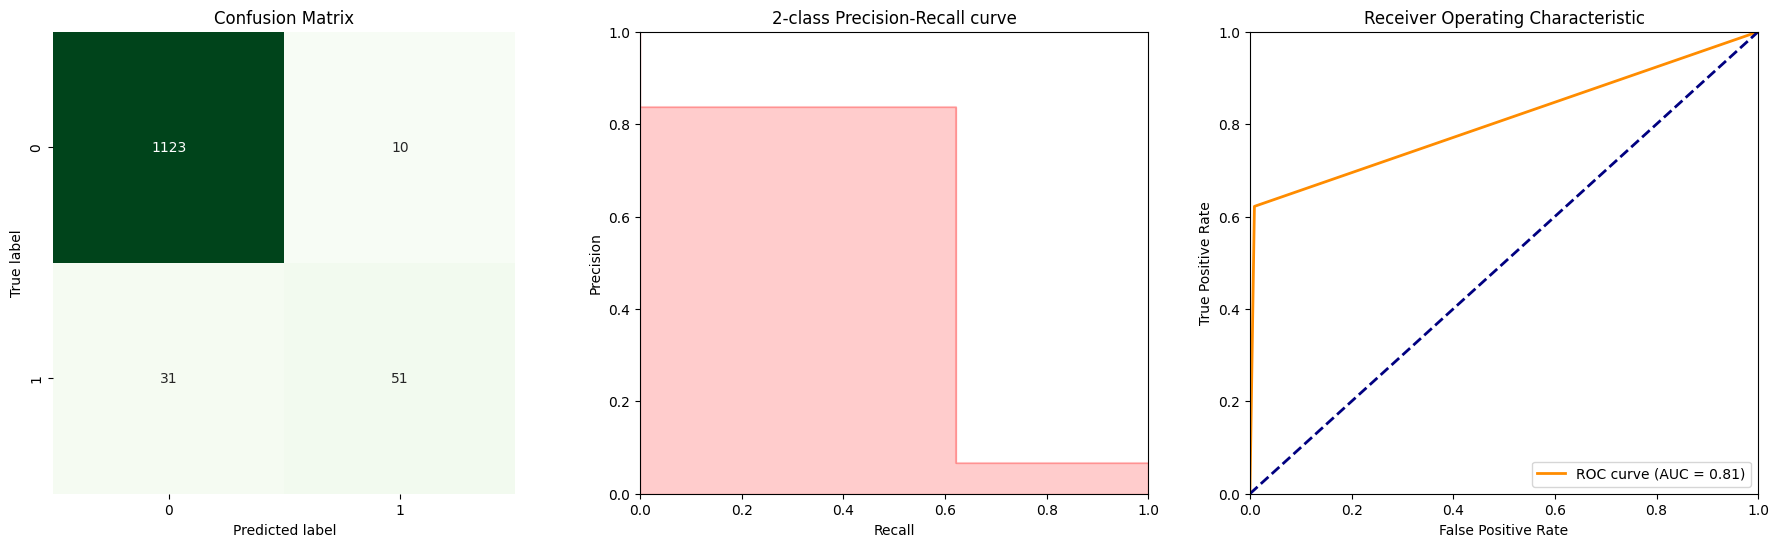

In [7]:
# Run this cell to generate a classification report with metrics and visuals

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of True instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [(2 * P * R) / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall.\n           Finds a balance in minimizing both false positives and false negatives.')

    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix (no .T)
    sns.heatmap(mat, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()


show_summary_report(y, y_pred_all)

In [9]:
#rfc_cv_results.to_csv('stored_results/Results_RFC_GS_Best_F1.csv', index=False)
#rfc_cv_results.to_csv('stored_results/Results_RFC_GS_Best_Recall.csv', index=False)
#rfc_cv_results.to_csv('stored_results/Results_RFC_GS_Best_Recall_Stratified_KFold.csv', index=False)

# Old version with no Gridsearch

In [3]:
rfc = RandomForestClassifier()

# Features
X = mlb_pitchers.drop(columns=['Hall of Fame', 'Player'])

# Target
y = mlb_pitchers['Hall of Fame']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [4]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(rfc, X, y, cv=kf)


# Get predicted probabilities
y_proba_all = cross_val_predict(rfc, X, y, cv=kf, method='predict_proba')

# Regular predictions
y_pred_all = cross_val_predict(rfc, X, y, cv=kf)


# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all])
confidence_scores = y_proba_all[np.arange(len(y_proba_all)), y_pred_indices]

# Build results dataframe
rfc_cv_results = pd.DataFrame()
rfc_cv_results['Player'] = mlb_pitchers['Player']
rfc_cv_results['Hall of Fame'] = y
rfc_cv_results['Prediction'] = y_pred_all
rfc_cv_results['Prediction Correct'] = (rfc_cv_results['Hall of Fame'] == rfc_cv_results['Prediction']).astype(int)
rfc_cv_results['Prediction Confidence'] = confidence_scores

#df['percentage_of_max'] = (df['values'] / max_value) * 100


rfc_cv_results

,Player,Hall of Fame,Prediction,Prediction Correct,Prediction Confidence
0,Cy Young,1,1,1,0.86
1,Pud Galvin,1,1,1,0.68
2,Walter Johnson,1,1,1,0.88
3,Phil Niekro,1,1,1,0.77
4,Nolan Ryan,1,1,1,0.82
...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.00
1211,Sammy Ellis,0,0,1,1.00
1212,Lil Stoner,0,0,1,1.00
1213,Johnny Humphries,0,0,1,1.00


In [5]:
rfc_cv_results.to_csv('Results RFC no GS.csv', index=False)

In [ ]:
rfc_cv_results['RFC Confidence Score'].hist(bins=20)
plt.title('Confidence vs Reality Distribution')
plt.xlabel('Confidence Score (+ = correct, - = wrong)')
plt.ylabel('Count')
plt.show()

# Adjusted Confidence Score

In [ ]:
# Score = +confidence if correct, -confidence if wrong
rfc_cv_results['RFC Confidence Score'] = np.where(
    rfc_cv_results['RFC Correct'] == 1,
    rfc_cv_results['RFC Confidence'],
    -rfc_cv_results['RFC Confidence']
)

# Make each result positive
rfc_cv_results['RFC Confidence Score'] = rfc_cv_results['RFC Confidence Score'] + 1

max_value = rfc_cv_results['RFC Confidence Score'].max()
rfc_cv_results['Confidence as Pct of Max'] = (rfc_cv_results['RFC Confidence Score'] / max_value) * 100

#df['percentage_of_max'] = (df['values'] / max_value) * 100


rfc_cv_results

In [24]:
import numpy as np

# signed score (you already have)
rfc_cv_results['RFC Signed Score'] = np.where(
    rfc_cv_results['RFC Correct'] == 1,
    rfc_cv_results['RFC Confidence'],
    -rfc_cv_results['RFC Confidence']
)

# Option 2: rescale signed score to [0,1]
rfc_cv_results['RFC Rescaled [0,1]'] = (1 + rfc_cv_results['RFC Signed Score']) / 2

# Option 3: reward positive, punishment mapped to (1 - p) so everything is in [0,1]
rfc_cv_results['RFC RewardPos'] = np.where(
    rfc_cv_results['RFC Correct'] == 1,
    rfc_cv_results['RFC Confidence'],
    1 - rfc_cv_results['RFC Confidence']
)

# Option 4: absolute confidence magnitude (loses correctness info)
rfc_cv_results['RFC AbsConfidence'] = rfc_cv_results['RFC Confidence'].abs()

# Example derived summaries
mean_signed = rfc_cv_results['RFC Signed Score'].mean()
mean_rescaled = rfc_cv_results['RFC Rescaled [0,1]'].mean()
mean_rewardpos = rfc_cv_results['RFC RewardPos'].mean()

print(f"Mean signed score ([-1,1]): {mean_signed:.4f}")
print(f"Mean rescaled score ([0,1]): {mean_rescaled:.4f}")
print(f"Mean reward-pos ([0,1]): {mean_rewardpos:.4f}")

Mean signed score ([-1,1]): 0.9063
Mean rescaled score ([0,1]): 0.9532
Mean reward-pos ([0,1]): 0.9417


In [25]:
rfc_cv_results

,Player,Hall of Fame,RFC Prediction,RFC Correct,RFC Confidence,RFC Signed Score,"RFC Rescaled [0,1]",RFC RewardPos,RFC AbsConfidence
0,Cy Young,1,1,1,0.91,0.91,0.955,0.91,0.91
1,Pud Galvin,1,1,1,0.59,0.59,0.795,0.59,0.59
2,Walter Johnson,1,1,1,0.89,0.89,0.945,0.89,0.89
3,Phil Niekro,1,1,1,0.77,0.77,0.885,0.77,0.77
4,Nolan Ryan,1,1,1,0.86,0.86,0.930,0.86,0.86
...,...,...,...,...,...,...,...,...,...
1210,Charlie Robertson,0,0,1,1.00,1.00,1.000,1.00,1.00
1211,Sammy Ellis,0,0,1,1.00,1.00,1.000,1.00,1.00
1212,Lil Stoner,0,0,1,1.00,1.00,1.000,1.00,1.00
1213,Johnny Humphries,0,0,1,1.00,1.00,1.000,1.00,1.00


In [28]:
rfc_cv_results.nsmallest(10, 'RFC Rescaled [0,1]')

,Player,Hall of Fame,RFC Prediction,RFC Correct,RFC Confidence,RFC Signed Score,"RFC Rescaled [0,1]",RFC RewardPos,RFC AbsConfidence
15,Roger Clemens,0,1,0,0.97,-0.97,0.015,0.03,0.97
91,Rube Marquard,1,0,0,0.97,-0.97,0.015,0.03,0.97
19,Tommy John,0,1,0,0.96,-0.96,0.020,0.04,0.96
105,Jesse Haines,1,0,0,0.96,-0.96,0.020,0.04,0.96
152,Jack Chesbro,1,0,0,0.92,-0.92,0.040,0.08,0.92
653,Andy Cooper,1,0,0,0.86,-0.86,0.070,0.14,0.86
246,Lefty Gomez,1,0,0,0.85,-0.85,0.075,0.15,0.85
257,John Ward,1,0,0,0.85,-0.85,0.075,0.15,0.85
23,Tony Mullane,0,1,0,0.83,-0.83,0.085,0.17,0.83
1174,Bruce Sutter,1,0,0,0.83,-0.83,0.085,0.17,0.83


# Histogram

In [ ]:
rfc_cv_results['RFC Confidence Score'].hist(bins=20)
plt.title('Confidence vs Reality Distribution')
plt.xlabel('Confidence Score (+ = correct, - = wrong)')
plt.ylabel('Count')
plt.show()